 # **This Technique apply only on  Normally Distributed Data**

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
df = pd.read_csv('placement.csv')

In [49]:
# Total Data
df.shape

(1000, 3)

In [50]:
df.sample(5)

,cgpa,placement_exam_marks,placed
954,8.00,39.0,1
707,6.86,11.0,1
20,6.69,47.0,0
561,7.07,58.0,0
971,6.69,18.0,1


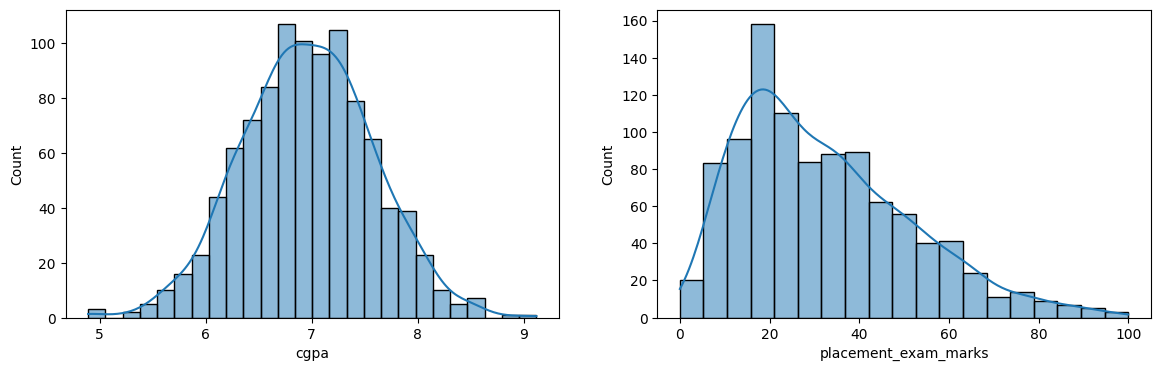

In [51]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(df['cgpa'] , kde=True)

plt.subplot(122)
sns.histplot(df['placement_exam_marks'] , kde=True)
plt.show()

In [52]:
print('CGPA Mean' , df['cgpa'].mean())
print('CGPA STD' , df['cgpa'].std())
print('CGPA Min' , df['cgpa'].min())
print('CGPA Max' , df['cgpa'].max())


CGPA Mean 6.96124
CGPA STD 0.6158978751323896
CGPA Min 4.89
CGPA Max 9.12


In [53]:
# Finding Boundries

# Highest boundries
print ('Highest boundry ' , df['cgpa'].mean() + 3 * df['cgpa'].std())
# lowest boundries

print ('Lower boundry ' , df['cgpa'].mean() - 3 * df['cgpa'].std())

Highest boundry  8.808933625397168
Lower boundry  5.113546374602832


In [54]:
# Finding Outlier

df[(df['cgpa'] > 8.80) | (df['cgpa'] < 5.11) ]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


# **Trimming Outliers with ranges**

In [55]:
Trim_Df = df[(df['cgpa'] < 8.80) & (df['cgpa'] > 5.11)]

In [56]:
Trim_Df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


# **Trimming Outliers  with zscore**

In [57]:
df['cgpa _zscore'] = (df['cgpa'] - df['cgpa'].mean()) / df['cgpa'].std() # Finding Z Score

In [58]:
df.head()

,cgpa,placement_exam_marks,placed,cgpa _zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [59]:
df[df['cgpa _zscore'] > 3] # values   with z score greater than 3 is outlier

,cgpa,placement_exam_marks,placed,cgpa _zscore
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062


In [60]:
df[df['cgpa _zscore'] < -3] # values   with z score lessthan than -3 is outlier

,cgpa,placement_exam_marks,placed,cgpa _zscore
485,4.92,44.0,1,-3.314251
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [61]:
df[(df['cgpa _zscore'] >3) | (df['cgpa _zscore'] < -3 )]

,cgpa,placement_exam_marks,placed,cgpa _zscore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [62]:
zscore_trim = df[(df['cgpa _zscore'] < 3) & (df['cgpa _zscore'] > -3 )]

In [63]:
zscore_trim

,cgpa,placement_exam_marks,placed,cgpa _zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


# **Capping With Limits**

In [64]:
upper_limit = df['cgpa'].mean() + 3 * df['cgpa'].std()
lower_limit =  df['cgpa'].mean() - 3 * df['cgpa'].std()

In [65]:
# np.where(conition , if true , false)

df['cgpa'] = np.where(
    df['cgpa'] > upper_limit,
    upper_limit,
    np.where(
        df['cgpa'] < lower_limit ,
        lower_limit,
        df['cgpa']
    )
)

In [66]:
df.shape

(1000, 4)

In [67]:
df['cgpa'].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64